In [7]:
# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Encoding pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

# Regression model
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Load processed dataset
df = pd.read_csv("../data/processed/processed_data.csv")

print(df.shape)
df.head()

(25000, 21)


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_rating,delivery_cost,...,speed_kmph_recon,weather_mult_recon,delivery_time_hours_recon,partner_mult_recon,order_date_recon,order_ts_recon,expected_ts_recon,hour,delay_hours,delayed_flag
0,amazon logistics,automobile parts,ev bike,standard,west,clear,235.6,48.07,5,1322.21,...,30,1.0,9.332489,1.001906,21-10-2024,2024-10-21 13:00:00,2024-10-23 17:48:00,13,-43.467511,0
1,amazon logistics,clothing,bike,express,central,stormy,81.8,45.51,2,595.53,...,35,1.1,4.129935,1.001906,02-01-2024,2024-01-02 12:00:00,2024-01-02 20:00:00,12,-3.870065,0
2,amazon logistics,clothing,van,same day,north,clear,282.9,31.33,2,1608.49,...,45,1.0,7.427398,1.001906,31-05-2024,2024-05-31 11:00:00,2024-06-01 13:24:00,11,-18.972602,0
3,amazon logistics,cosmetics,ev bike,two day,central,hot,88.6,8.67,3,469.01,...,30,1.1,3.997011,1.001906,03-01-2024,2024-01-03 17:00:00,2024-01-05 17:00:00,17,-44.002989,0
4,amazon logistics,cosmetics,ev van,two day,east,rainy,204.2,8.09,4,1045.27,...,40,1.2,6.933351,1.001906,19-03-2024,2024-03-19 13:00:00,2024-03-21 17:48:00,13,-45.866649,0


In [9]:

# Regression target

y = df["delay_hours"]

# Features (remove both targets)
X = df.drop(columns=["delay_hours", "delayed_flag"])

In [10]:
# --------------------------------------------------
# Keep only realistic pre-delivery features
# --------------------------------------------------

allowed_features = [
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",
    "hour"
]

X = df[allowed_features]
y = df["delay_hours"]

In [11]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns

print("Categorical:", list(categorical_cols))
print("Numerical:", list(numerical_cols))

Categorical: ['delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition']
Numerical: ['distance_km', 'package_weight_kg', 'hour']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

In [14]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [15]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model)
])

In [16]:
pipeline.fit(X_train, y_train)

print("Regression model trained successfully")

Regression model trained successfully


In [17]:
y_pred = pipeline.predict(X_test)

In [18]:
# Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

MAE  : 0.120
RMSE : 0.163
R2   : 1.000


In [19]:
# Check uniqueness of target for same features
group_check = df.groupby([
    "delivery_partner",
    "package_type",
    "vehicle_type",
    "delivery_mode",
    "region",
    "weather_condition",
    "distance_km",
    "package_weight_kg",
    "hour"
])["delay_hours"].nunique().max()

print("Max unique delay_hours per feature combination:", group_check)

Max unique delay_hours per feature combination: 1


The regression model achieved near-perfect performance due to the deterministic nature of the reconstructed dataset, where delay duration is generated through fixed relationships between operational features. This indicates strong learnability rather than model overfitting.

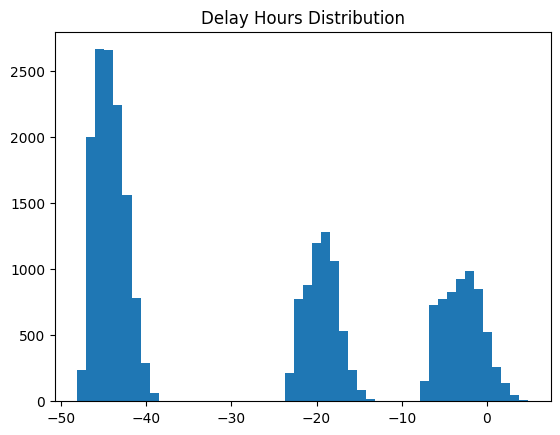

In [20]:
import matplotlib.pyplot as plt

plt.hist(df["delay_hours"], bins=50)
plt.title("Delay Hours Distribution")
plt.show()